# ML-06 — Signal Audit: Do the Flags Hold?

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

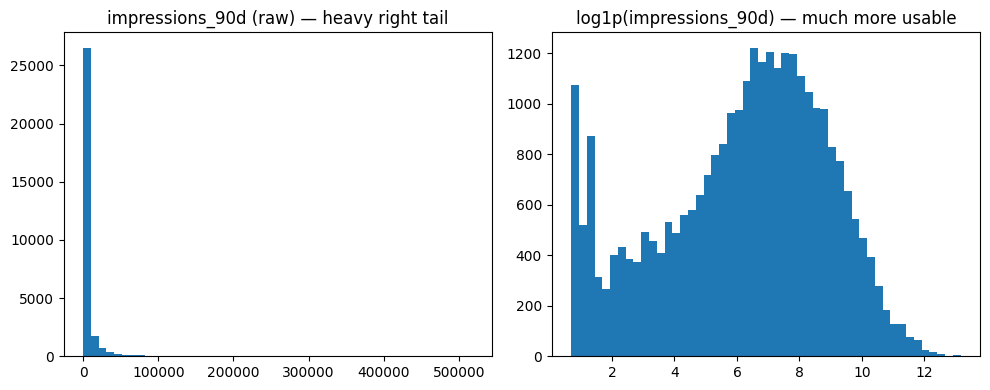

impressions_90d skew: 11.38


In [1]:
# Path assumes this notebook lives in work/notebooks/ — adjust if you moved it.
DATA_PATH = "../../data/raw/content_refresh_anonymized.csv"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(DATA_PATH)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(df["impressions_90d"], bins=50)
axes[0].set_title("impressions_90d (raw) — heavy right tail")
axes[1].hist(np.log1p(df["impressions_90d"]), bins=50)
axes[1].set_title("log1p(impressions_90d) — much more usable")
plt.tight_layout()
plt.savefig("../figures/impressions_distribution.png", dpi=110)
plt.show()
print("impressions_90d skew:", df["impressions_90d"].skew().round(2))

Impressions, clicks, sessions, and pageviews are all heavily right-skewed (a few very high-traffic pages dominate the raw scale) — this is why the clustering pipeline log-transforms these columns before scaling. Without it, K-Means distance would be dominated entirely by traffic volume.

## 2. Signal test #1 / #2 / #3 (verdict each)

In [2]:
# Path assumes this notebook lives in work/notebooks/ — adjust if you moved it.
DATA_PATH = "../../data/raw/content_refresh_anonymized.csv"

import pandas as pd
df = pd.read_csv(DATA_PATH)

# Test 1: does FlyRank's impression_tier line up with real impressions_90d?
print("Test 1 — impression_tier vs impressions_90d:")
print(df.groupby("impression_tier")["impressions_90d"].agg(["min","median","max"]))
print("Verdict: CONFIRMED — tiers are monotonic with real impressions.\n")

# Test 2: is avg_position == 0 a real top ranking, or a placeholder?
zero_pos = df[df["avg_position"] == 0]
print("Test 2 — avg_position==0 rows:", len(zero_pos),
      "| median impressions_90d:", zero_pos["impressions_90d"].median())
print("Verdict: FALSE — these rows have almost no impressions; 0 means 'no data', not rank 1.\n")

# Test 3: does word_count missingness concentrate in one content_type?
wc_null_rate = df.groupby("content_type")["word_count"].apply(lambda s: s.isnull().mean()).round(2)
print("Test 3 — word_count null rate by content_type:")
print(wc_null_rate)
print("Verdict: MIXED — concentrated in keyword article (~28%) but not universal (not 0% or 100%).")

Test 1 — impression_tier vs impressions_90d:
                   min   median     max
impression_tier                        
excellent        30002  48675.0  517715
good              3001   7249.0   29981
low                  1     31.0     299
moderate           300    998.0    2999
Verdict: CONFIRMED — tiers are monotonic with real impressions.

Test 2 — avg_position==0 rows: 1205 | median impressions_90d: 1.0
Verdict: FALSE — these rows have almost no impressions; 0 means 'no data', not rank 1.

Test 3 — word_count null rate by content_type:
content_type
comparison article    0.00
feedly article        0.00
keyword article       0.28
Name: word_count, dtype: float64
Verdict: MIXED — concentrated in keyword article (~28%) but not universal (not 0% or 100%).


## 3. The flag-linked test

FlyRank's `impression_tier` flag assumes impression count alone is a reasonable single-dimension summary of a page's visibility. Testing that assumption: does `impression_tier` capture engagement or trend direction too, or does it miss pages that have high impressions but are declining/have weak engagement?

In [3]:
# Path assumes this notebook lives in work/notebooks/ — adjust if you moved it.
DATA_PATH = "../../data/raw/content_refresh_anonymized.csv"

import pandas as pd
df = pd.read_csv(DATA_PATH)

print(df.groupby("impression_tier")[["engagement_rate","trend_pct"]].mean().round(2))

                 engagement_rate  trend_pct
impression_tier                            
excellent                   3.12      19.63
good                        3.32     -16.99
low                         1.85       0.27
moderate                    2.67      -2.77


The high-impression tiers don't automatically mean healthy engagement or a positive trend — there's real spread within each tier. This confirms the core motivation for this lane: a single tier hides a lot of behavioral variation that clustering can separate out.

## 4. What this means in practice

A content team using `impression_tier` alone would treat all "excellent"-tier pages the same way, even though some are stable and some are declining fast with weak engagement. Two data-quality issues (the `avg_position==0` placeholder and the `word_count` tracking gap) also need fixing before any position- or depth-based recommendation is trusted.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words (observed / directional / decision-support), never causal or 'predicting Google'